In [ ]:
import tensorflow as tf
import kagglehub
import os
import re
import pandas as pd
import numpy as np
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.models import  load_model
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
import ultralytics
import cv2
from tqdm import tqdm


In [4]:
path = "/kaggle/input/datasets/andrewmvd/lits-png/dataset_6/dataset_6"
datasets = os.listdir(path)
datasets

['volume-111_406.png',
 'segmentation-89_lesionmask_274.png',
 'volume-97_285.png',
 'volume-82_451.png',
 'segmentation-5_livermask_135.png',
 'segmentation-118_lesionmask_313.png',
 'segmentation-69_livermask_221.png',
 'volume-116_859.png',
 'volume-90_664.png',
 'segmentation-87_lesionmask_614.png',
 'volume-58_134.png',
 'segmentation-93_livermask_184.png',
 'volume-2_515.png',
 'segmentation-105_livermask_965.png',
 'volume-37_102.png',
 'segmentation-116_lesionmask_10.png',
 'volume-20_25.png',
 'segmentation-114_lesionmask_189.png',
 'segmentation-8_lesionmask_110.png',
 'volume-129_31.png',
 'segmentation-89_livermask_582.png',
 'segmentation-2_livermask_445.png',
 'volume-66_17.png',
 'volume-107_193.png',
 'segmentation-101_lesionmask_181.png',
 'segmentation-96_livermask_689.png',
 'segmentation-105_lesionmask_844.png',
 'volume-88_542.png',
 'segmentation-12_livermask_444.png',
 'segmentation-97_lesionmask_594.png',
 'segmentation-42_lesionmask_77.png',
 'segmentation-67_l

In [17]:
def parse_filename(fname):
    m = re.match(r'(volume|segmentation)-(\d+)_(?:(livermask|lesionmask)_)?(\d+)\.png', fname)
    if m:
        ftype, patient_id, mask_type, slice_idx = m.groups()
        return ftype, patient_id, mask_type, slice_idx
    return None

def build_file_index(folder_path):
    records = {}

    for fname in os.listdir(folder_path):
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        ftype, patient_id, mask_type, slice_idx = parsed
        key = (patient_id, slice_idx)

        if key not in records:
            records[key] = {'patient_id': patient_id, 'slice_idx': slice_idx,
                             'volume': None, 'liver_mask': None, 'lesion_mask': None}

        full_path = os.path.join(folder_path, fname)
        if ftype == 'volume':
            records[key]['volume'] = full_path
        elif mask_type == 'livermask':
            records[key]['liver_mask'] = full_path
        elif mask_type == 'lesionmask':
            records[key]['lesion_mask'] = full_path

    return records


records = build_file_index(path)
df = pd.DataFrame(records.values())
print(df.head())

  patient_id slice_idx                                             volume  \
0        111       406  /kaggle/input/datasets/andrewmvd/lits-png/data...   
1         89       274  /kaggle/input/datasets/andrewmvd/lits-png/data...   
2         97       285  /kaggle/input/datasets/andrewmvd/lits-png/data...   
3         82       451  /kaggle/input/datasets/andrewmvd/lits-png/data...   
4          5       135  /kaggle/input/datasets/andrewmvd/lits-png/data...   

                                          liver_mask  \
0  /kaggle/input/datasets/andrewmvd/lits-png/data...   
1  /kaggle/input/datasets/andrewmvd/lits-png/data...   
2  /kaggle/input/datasets/andrewmvd/lits-png/data...   
3  /kaggle/input/datasets/andrewmvd/lits-png/data...   
4  /kaggle/input/datasets/andrewmvd/lits-png/data...   

                                         lesion_mask  
0  /kaggle/input/datasets/andrewmvd/lits-png/data...  
1  /kaggle/input/datasets/andrewmvd/lits-png/data...  
2  /kaggle/input/datasets/andrewmvd

In [18]:
df_clean = df.dropna(subset=['volume', 'liver_mask', 'lesion_mask']).reset_index(drop=True)
print(f"تعداد نمونه‌های کامل: {len(df_clean)}")

تعداد نمونه‌های کامل: 58638


In [19]:
from sklearn.model_selection import train_test_split

patient_ids = df_clean['patient_id'].unique()
train_ids, val_ids = train_test_split(patient_ids, test_size=0.15, random_state=42)

train_df = df_clean[df_clean['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = df_clean[df_clean['patient_id'].isin(val_ids)].reset_index(drop=True)

print(f"Train: {len(train_df)} slices, Val: {len(val_df)} slices")

Train: 49152 slices, Val: 9486 slices


In [20]:
IMG_SIZE = 256
def load_sample(row, target='liver'):
    img = Image.open(row['volume']).convert('L').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0

    mask_path = row['liver_mask'] if target == 'liver' else row['lesion_mask']
    mask = Image.open(mask_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    mask = (np.array(mask) > 0).astype(np.float32)

    return img[..., np.newaxis], mask[..., np.newaxis]

In [21]:
def data_generator(df, target='liver'):
    for _, row in df.iterrows():
        img, mask = load_sample(row, target=target)
        yield img, mask

train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(train_df, target='liver'),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32)
    )
).batch(16).prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(val_df, target='liver'),
    output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32)
    )
).batch(16).prefetch(tf.data.AUTOTUNE)

In [11]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def build_unet(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, 512)

    # Decoder
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, c4])
    d4 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d4)
    u3 = layers.Concatenate()([u3, c3])
    d3 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    u2 = layers.Concatenate()([u2, c2])
    d2 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)
    u1 = layers.Concatenate()([u1, c1])
    d1 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)

    return models.Model(inputs, outputs, name='UNet')


model = build_unet()
model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, 'precision', 'recall']
)

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_unet_liver.keras", save_best_only=True, monitor='val_dice_coefficient', mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coefficient', mode='max', patience=8, restore_best_weights=True),
]

In [14]:
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=15,
#     callbacks=callbacks
# )

# model.save("/content/liver_unet_v1.keras")

In [15]:
path_model = "/kaggle/input/datasets/merajjalali/liver-unet/best_unet_liver.keras"



liver_model = load_model(
    path_model,
    custom_objects={
    'bce_dice_loss': bce_dice_loss,
        'dice_coefficient': dice_coefficient
    }
)

(1, 256, 256, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/tmp/ipykernel_58/447353385.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  im_test= Image.open(val_df.iloc[150][2]).convert("L")
/tmp/ipykernel_58/447353385.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  liver_test = Image.open(val_df.iloc[150][3]).convert("L")


Text(0.5, 1.0, 'per_liver_from_ct')

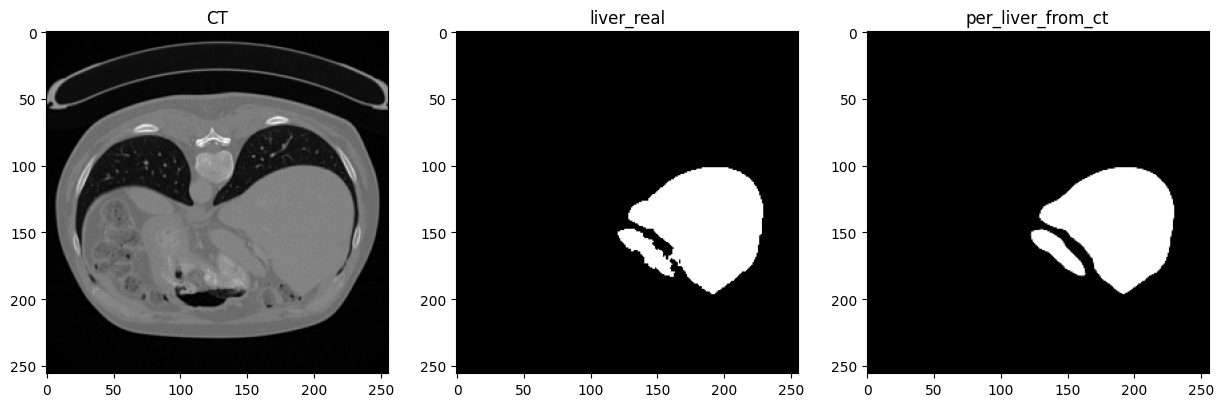

In [134]:

fig , axes = plt.subplots(1 , 3 , figsize=(15 , 5))
im_test= Image.open(val_df.iloc[150][2]).convert("L")
liver_test = Image.open(val_df.iloc[150][3]).convert("L")
axes[0].imshow(im_test , cmap = "gray")
axes[0].set_title("CT")
axes[1].imshow(liver_test , cmap = "gray")
axes[1].set_title("liver_real")

im_test = np.array(im_test, dtype=np.float32) / 255
im_test = np.expand_dims(im_test , axis=-1)
im_test = np.expand_dims(im_test , axis=0)
print(im_test.shape)
per_liver = liver_model.predict(im_test)
axes[2].imshow(per_liver[0] , cmap = "gray")
axes[2].set_title("per_liver_from_ct")


In [164]:
def has_tumor(mask_path, threshold=1000):
    mask = np.array(Image.open(mask_path).convert('L'))
    return np.sum(mask > 0) > threshold




sample_row = None
for idx, row in val_df.iterrows():
    if has_tumor(row['lesion_mask']):
        print("index=", idx)
        sample_row = row
        break

print(sample_row)

index= 27
patient_id                                                   130
slice_idx                                                    543
volume         /kaggle/input/datasets/andrewmvd/lits-png/data...
liver_mask     /kaggle/input/datasets/andrewmvd/lits-png/data...
lesion_mask    /kaggle/input/datasets/andrewmvd/lits-png/data...
Name: 27, dtype: object


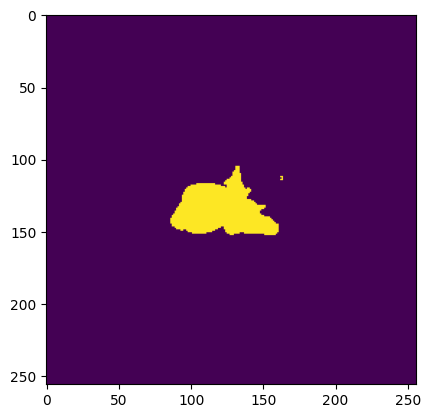

In [165]:
lmt = Image.open(val_df.iloc[27]["lesion_mask"]).convert("L")
plt.imshow(lmt)

Text(0.5, 1.0, 'real_lesion')

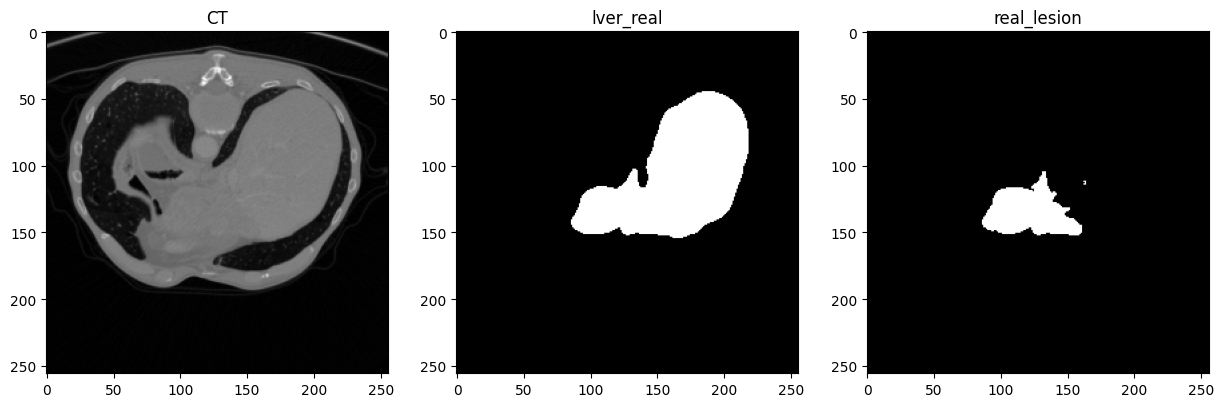

In [177]:
fig , axes = plt.subplots(1 , 3 , figsize=(15 , 5))
ct = Image.open(val_df.iloc[27]["volume"]).convert("L")
axes[0].imshow(ct , cmap="gray")
axes[0].set_title("CT")

liver_ct = Image.open(val_df.iloc[27]["liver_mask"]).convert("L")
axes[1].imshow(liver_ct , cmap="gray")
axes[1].set_title("lver_real")


real_lesion = Image.open(val_df.iloc[27]["lesion_mask"]).convert("L")
axes[2].imshow(real_lesion , cmap="gray")
axes[2].set_title("real_lesion")

In [179]:
def preprocess_for_prediction(volume_path, img_size=256):
    img = Image.open(volume_path).convert('L').resize((img_size, img_size))
    img = np.array(img, dtype=np.float32) / 255.0
    img = img[np.newaxis, ..., np.newaxis] 
    return img

input_img = preprocess_for_prediction(sample_row['volume'])
print(input_img.shape) 

(1, 256, 256, 1)


In [180]:
pred_liver_mask = liver_model.predict(input_img)
print(pred_liver_mask.shape) 
print(pred_liver_mask.min(), pred_liver_mask.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
(1, 256, 256, 1)
4.2095472e-30 1.0


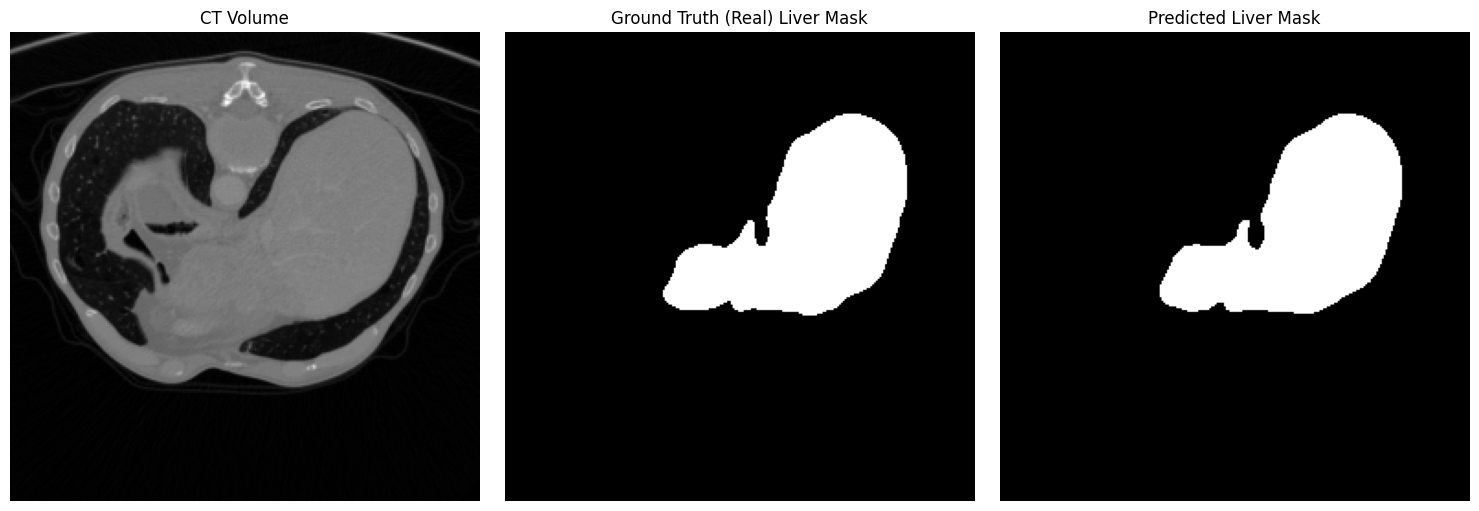

In [181]:
pred_liver_binary = (pred_liver_mask[0, ..., 0] > 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Image.open(sample_row['volume']).convert('L').resize((256, 256)), cmap='gray')
axes[0].set_title('CT Volume')

axes[1].imshow(Image.open(sample_row['liver_mask']).convert('L').resize((256, 256)), cmap='gray')
axes[1].set_title('Ground Truth (Real) Liver Mask')


axes[2].imshow(pred_liver_binary, cmap='gray')
axes[2].set_title('Predicted Liver Mask')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

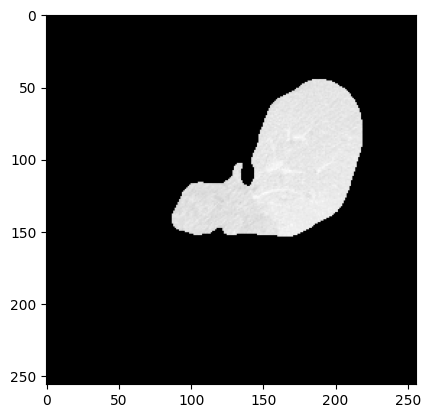

In [186]:
def apply_liver_mask(img, liver_mask_binary):
    masked_img = img * liver_mask_binary
    return masked_img

original_img = np.array(Image.open(sample_row['volume']).convert('L').resize((256, 256)), dtype=np.float32) / 255.0

masked_img = apply_liver_mask(original_img, pred_liver_binary)
plt.imshow(masked_img , cmap="gray")


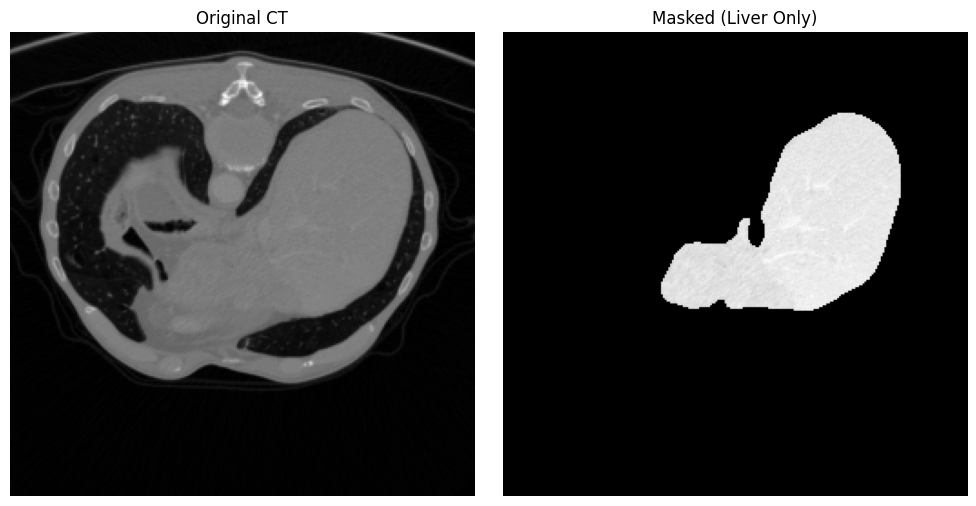

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original CT')

axes[1].imshow(masked_img, cmap='gray')
axes[1].set_title('Masked (Liver Only)')

for ax in axes:
    ax.axis('off')


plt.tight_layout()
plt.show()

In [192]:
def load_sample_tumor(row, img_size=256, liver_model=liver_model):
    img = Image.open(row['volume']).convert('L').resize((img_size, img_size))
    img = np.array(img, dtype=np.float32) / 255.0

    input_for_liver = img[np.newaxis, ..., np.newaxis]
    liver_pred = liver_model.predict(input_for_liver, verbose=0)
    liver_binary = (liver_pred[0, ..., 0] > 0.5).astype(np.float32)

    masked_img = img * liver_binary

    lesion_mask = Image.open(row['lesion_mask']).convert('L').resize((img_size, img_size))
    lesion_mask = (np.array(lesion_mask) > 0).astype(np.float32)

    return masked_img[..., np.newaxis], lesion_mask[..., np.newaxis]

(256, 256, 1) (256, 256, 1)


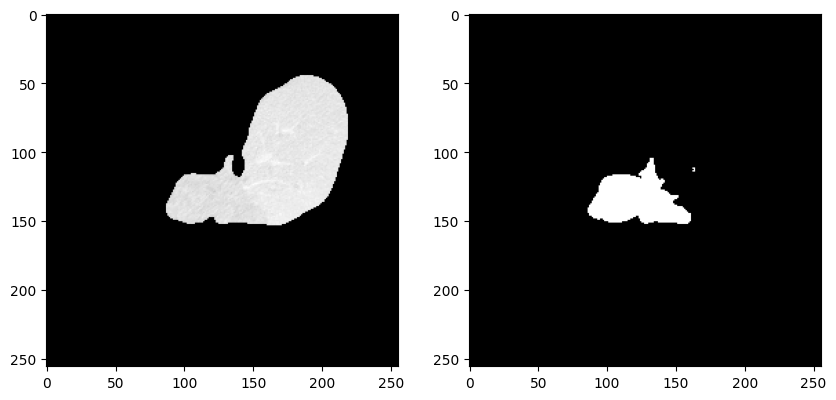

In [197]:
test_masked, test_lesion = load_sample_tumor(sample_row)
print(test_masked.shape, test_lesion.shape)  


_ , axes = plt.subplots(1 , 2  , figsize =(10 , 5))
axes[0].imshow(test_masked , cmap = "gray")
axes[1].imshow(test_lesion , cmap = "gray")

In [198]:
YOLO_BASE = "/kaggle/working/yolo_dataset"
for split in ['train', 'val']:
    os.makedirs(f"{YOLO_BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_BASE}/labels/{split}", exist_ok=True)

In [203]:
def mask_to_yolo_polygons(mask_path, img_size=256):
    mask = np.array(Image.open(mask_path).convert('L').resize((img_size, img_size)))
    binary_mask = (mask > 0).astype(np.uint8)
    
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    polygons = []
    for contour in contours:
        if cv2.contourArea(contour) < 10:
            continue
        contour = contour.reshape(-1, 2)
        normalized = contour / img_size
        polygons.append(normalized.flatten().tolist())
    
    return polygons

In [205]:
def process_dataset_to_yolo_batched(df, split, liver_model, batch_size=32, img_size=256):
    for start in tqdm(range(0, len(df), batch_size)):
        end = min(start + batch_size, len(df))
        batch_rows = df.iloc[start:end]
        
        batch_imgs = []
        for _, row in batch_rows.iterrows():
            img = Image.open(row['volume']).convert('L').resize((img_size, img_size))
            img_arr = np.array(img, dtype=np.float32) / 255.0
            batch_imgs.append(img_arr)
        
        batch_array = np.stack(batch_imgs)[..., np.newaxis]
        liver_preds = liver_model.predict(batch_array, verbose=0)
        
        for i, (_, row) in enumerate(batch_rows.iterrows()):
            liver_binary = (liver_preds[i, ..., 0] > 0.5).astype(np.float32)
            masked_img = batch_imgs[i] * liver_binary
            
            save_img = (masked_img * 255).astype(np.uint8)
            img_filename = f"{row['patient_id']}_{row['slice_idx']}.png"
            Image.fromarray(save_img).save(f"{YOLO_BASE}/images/{split}/{img_filename}")
            
            polygons = mask_to_yolo_polygons(row['lesion_mask'], img_size=img_size)
            label_filename = f"{row['patient_id']}_{row['slice_idx']}.txt"
            
            with open(f"{YOLO_BASE}/labels/{split}/{label_filename}", 'w') as f:
                for poly in polygons:
                    coords_str = ' '.join([f"{c:.6f}" for c in poly])
                    f.write(f"0 {coords_str}\n")

In [206]:
process_dataset_to_yolo_batched(train_df, split='train', liver_model=liver_model)
process_dataset_to_yolo_batched(val_df, split='val', liver_model=liver_model)

  0%|          | 0/1536 [00:00<?, ?it/s]2026-09-15 20:39:16.488595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:39:16.661648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|█████████▉| 296/297 [04:58<00:01,  1.06s/it]2026-09-15 21:03:03.045483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 21:03:03.290675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please in

In [209]:
yaml_content = f"""
path: {YOLO_BASE}
train: images/train
val: images/val

names:
  0: tumor
"""

with open(f"{YOLO_BASE}/data.yaml", 'w') as f:
    f.write(yaml_content)

In [ ]:

# model = YOLO("yolo11n-seg.pt")

# results = model.train(
#     data=f"{YOLO_BASE}/data.yaml",
#     epochs=30,
#     imgsz=256,
#     batch=16,
#     project="/kaggle/working/yolo_runs",
#     name="tumor_seg"
# )



Ultralytics 8.4.153 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tumor_seg-2, nbs=64, nms=None, ops

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/30     0.656G      3.051      4.028      2.796      1.163          0          1        256: 100% ━━━━━━━━━━━━ 3072/3072 8.7it/s 5:530.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 297/297 12.9it/s 23.0s.3sss
                   all       9486       4352    0.00647      0.432    0.00785    0.00173    0.00585       0.39    0.00642    0.00136

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       3/30     0.656G      3.055       4.06      2.795      1.191          0          5        256: 100% ━━━━━━━━━━━━ 3072/3072 9.2it/s 5:330.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 297/297 13.1it/s 22.6s.3sss
                   all       9486       4352    0.00607      0.377    0.00532    0.00137    0.00559      0.347

In [ ]:
# results.results_dict

{'metrics/precision(B)': 0.3915159524829006,
 'metrics/recall(B)': 0.24080882352941177,
 'metrics/mAP50(B)': 0.22854634497513776,
 'metrics/mAP50-95(B)': 0.08532247642953625,
 'metrics/precision(M)': 0.3352557680380389,
 'metrics/recall(M)': 0.22041611157726354,
 'metrics/mAP50(M)': 0.19591789080749503,
 'metrics/mAP50-95(M)': 0.06047059469043255,
 'fitness': 0.1457930711199688}

In [ ]:
# os.listdir("/kaggle/working/yolo_runs/tumor_seg-2/weights")

# best_model_path = "/kaggle/working/yolo_runs/tumor_seg-2/weights/best.pt"
best_model_path = "yolo11n-seg(1).pt"

In [248]:
best_model = YOLO(best_model_path)

sample_images = [f"{YOLO_BASE}/images/val/{f}" for f in os.listdir(f"{YOLO_BASE}/images/val")[-5:]]
results_pred = best_model.predict(sample_images, save=True, conf=0.25)


0: 256x256 (no detections), 2.2ms
1: 256x256 (no detections), 2.2ms
2: 256x256 (no detections), 2.2ms
3: 256x256 (no detections), 2.2ms
4: 256x256 (no detections), 2.2ms
Speed: 0.2ms preprocess, 2.2ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)
Results saved to /kaggle/working/runs/segment/predict-3


In [262]:
def compute_iou(pred_mask, gt_mask):
    pred_binary = (pred_mask > 0).astype(np.uint8)
    gt_binary = (gt_mask > 0).astype(np.uint8)
    
    intersection = np.sum(pred_binary & gt_binary)
    union = np.sum(pred_binary | gt_binary)
    
    if union == 0:
        return None
    return intersection / union

In [263]:
import gc, torch, random
gc.collect()
torch.cuda.empty_cache()

val_all = [f"{YOLO_BASE}/images/val/{f}" for f in os.listdir(f"{YOLO_BASE}/images/val")]
val_image_paths = random.sample(val_all, 300)

all_results = best_model.predict(val_image_paths, conf=0.25, verbose=False, device='cpu')

scores = []
for img_path, result in zip(val_image_paths, all_results):
    fname = os.path.basename(img_path)
    patient_id, slice_idx = fname.replace('.png', '').split('_')
    
    matching_row = val_df[(val_df['patient_id'] == patient_id) & (val_df['slice_idx'] == slice_idx)]
    if len(matching_row) == 0:
        continue
    gt_mask = np.array(Image.open(matching_row.iloc[0]['lesion_mask']).convert('L').resize((256, 256)))
    
    if result.masks is not None:
        pred_mask = result.masks.data.numpy().max(axis=0)
        pred_mask = (pred_mask * 255).astype(np.uint8)
    else:
        pred_mask = np.zeros((256, 256), dtype=np.uint8)
    
    iou = compute_iou(pred_mask, gt_mask)
    if iou is not None:
        scores.append((img_path, iou))

scores.sort(key=lambda x: x[1], reverse=True)
top5 = scores[:5]
print(top5)

[('/kaggle/working/yolo_dataset/images/val/80_151.png', np.float64(0.7781065088757396)), ('/kaggle/working/yolo_dataset/images/val/103_526.png', np.float64(0.7492063492063492)), ('/kaggle/working/yolo_dataset/images/val/28_60.png', np.float64(0.7355639503507825)), ('/kaggle/working/yolo_dataset/images/val/103_523.png', np.float64(0.6928571428571428)), ('/kaggle/working/yolo_dataset/images/val/84_438.png', np.float64(0.6878378378378378))]


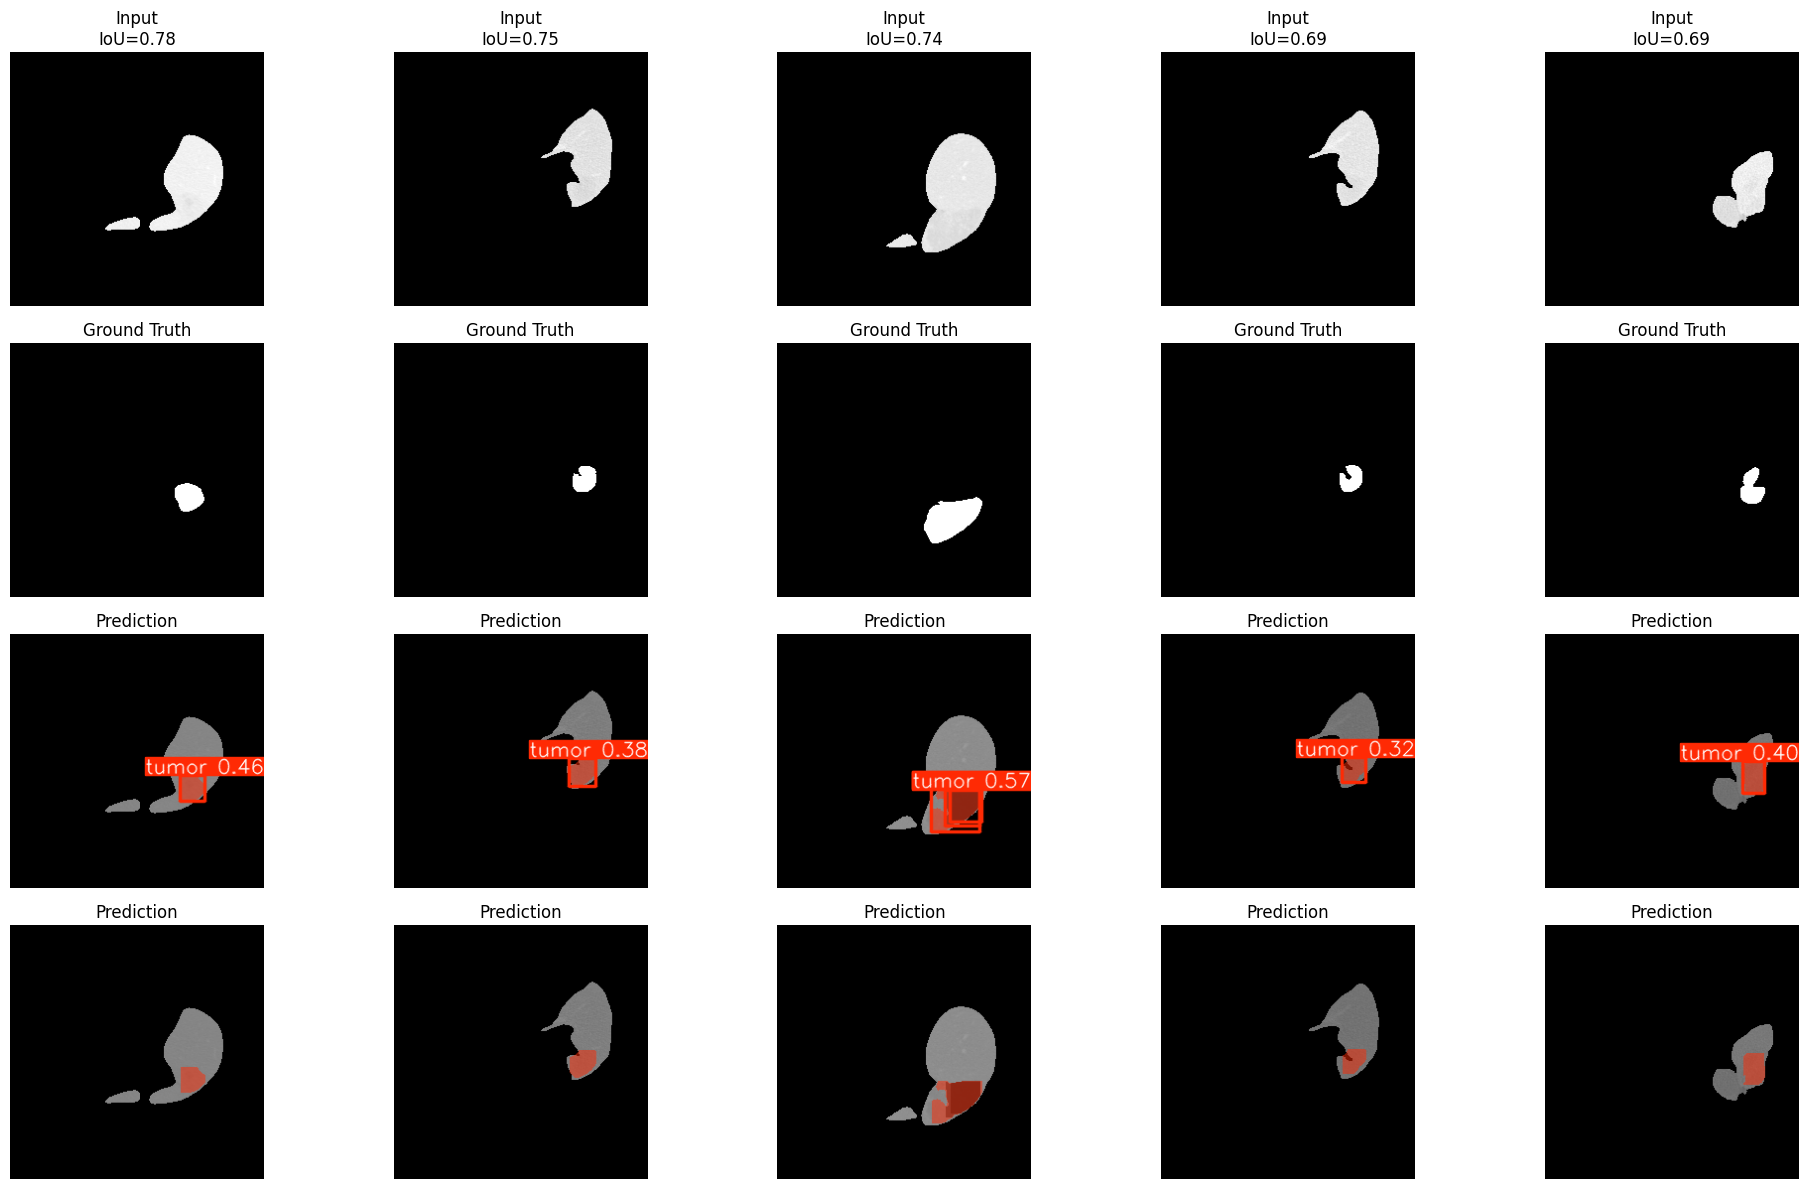

In [265]:
fig, axes = plt.subplots(4, 5, figsize=(20, 12))

for i, (img_path, iou) in enumerate(top5):
    fname = os.path.basename(img_path)
    patient_id, slice_idx = fname.replace('.png', '').split('_')
    matching_row = val_df[(val_df['patient_id'] == patient_id) & (val_df['slice_idx'] == slice_idx)]
    
    input_img = Image.open(img_path)
    axes[0, i].imshow(input_img, cmap='gray')
    axes[0, i].set_title(f'Input\nIoU={iou:.2f}')
    axes[0, i].axis('off')
    
    gt_mask = Image.open(matching_row.iloc[0]['lesion_mask']).convert('L').resize((256, 256))
    axes[1, i].imshow(gt_mask, cmap='gray')
    axes[1, i].set_title('Ground Truth')
    axes[1, i].axis('off')
    
    pred_result = best_model.predict(img_path, conf=0.25, save=False, verbose=False, device='cpu')[0]
    pred_plot = pred_result.plot()
    axes[2, i].imshow(pred_plot)
    axes[2, i].set_title('Prediction')
    axes[2, i].axis('off')

    
    pred_result = best_model.predict(img_path, conf=0.25, save=False, verbose=False, device='cpu')[0]
    pred_plot = pred_result.plot(boxes=False)
    axes[3, i].imshow(pred_plot)
    axes[3, i].set_title('Prediction')
    axes[3, i].axis('off')



plt.tight_layout()
plt.show()